structure du projet 
4) Installer et importer seaborn, matplotlib, pandas, numpy

In [44]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


5) Importer mesures_capteurs.csv dans le dataframe df

In [45]:
df = pd.read_csv("../data/mesures_capteurs.csv")

6) Vérifier le contenu du dataframe df

In [46]:
print(df)

    id_mesure           date_heure id_capteur batiment  temperature  humidite  \
0       M0413  2026-01-22 04:00:00       C005     B002        25.46     58.06   
1       M0290  2026-01-17 01:00:00       C002     B001        24.00     79.73   
2       M0077  2026-01-08 04:00:00       C005     B002        25.82     54.47   
3       M0079  2026-01-08 06:00:00       C007     B003        28.23     69.39   
4       M0183  2026-01-12 14:00:00       C003     B001        20.58     53.80   
..        ...                  ...        ...      ...          ...       ...   
600     M0072  2026-01-07 23:00:00       C012     B004        23.67     60.28   
601     M0107  2026-01-09 10:00:00       C011     B004        24.34     61.42   
602     M0271  2026-01-16 06:00:00       C007     B003        23.73     63.49   
603     M0436  2026-01-23 03:00:00       C004     B002        24.83     79.77   
604     M0103  2026-01-09 06:00:00       C007     B003        17.02     52.04   

     pression  consommation

Partie 1 – Distribution d'une variable avec histplot()
1) Afficher la distribution des températures

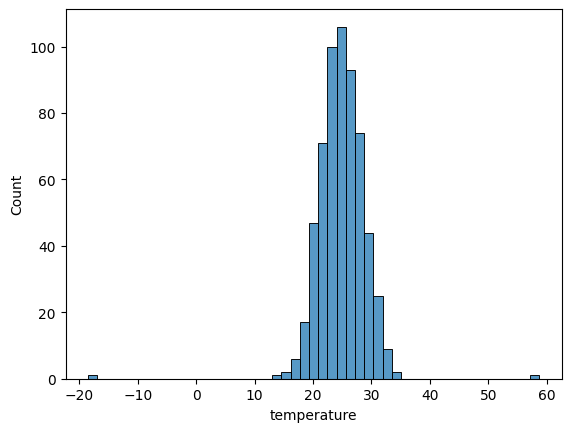

In [47]:
sns.histplot(data=df, x="temperature")

plt.show()

2) Autour de quelle valeur les températures sont concentrées ?

les temperatures sont plus concentrées autour de 20 et 30 

3) La distribution semble-t-elle symétrique ?

oui la distribution semble symétrique

4) Existe-t-il des valeurs extrêmes ?

oui il existe des valeurs extremes

5) Modifier le nombre de classes

<Axes: xlabel='temperature', ylabel='Count'>

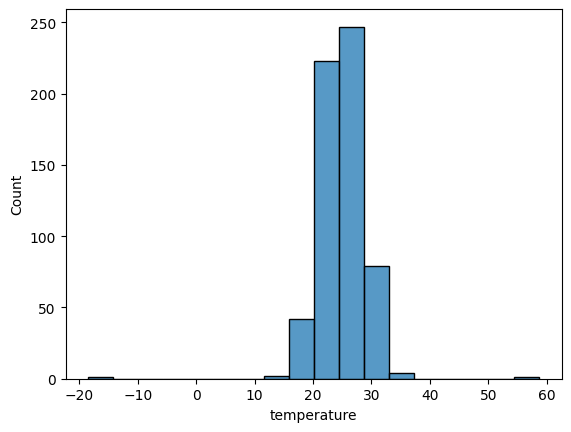

In [48]:
sns.histplot(data=df, x="temperature", bins=18)

6) Afficher la distribution des températures par bâtiment

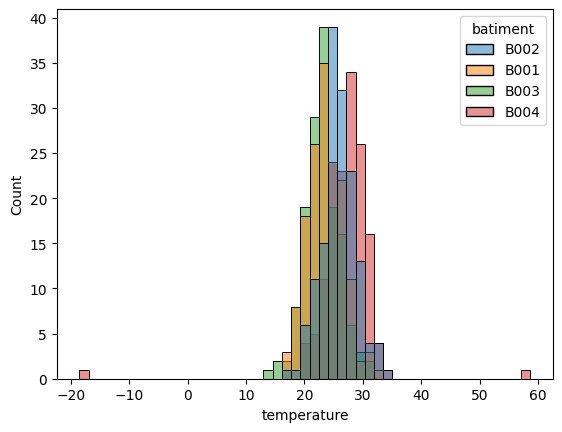

In [49]:
sns.histplot(
    data=df,
    x="temperature",
    hue="batiment"
)

plt.show()

Partie 2 – Distribution d'une variable avec kdeplot()
1) Afficher la distribution des températures

<Axes: xlabel='temperature', ylabel='Density'>

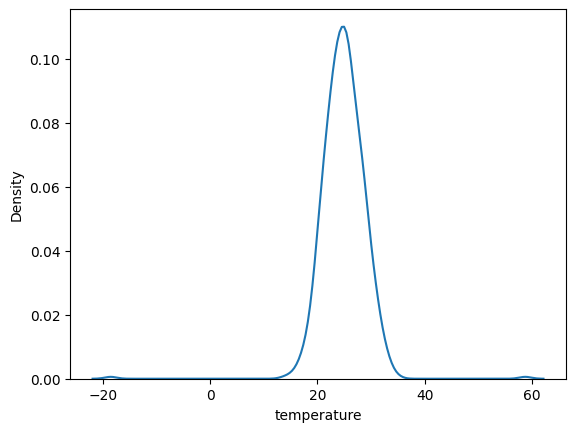

In [50]:
sns.kdeplot(data=df, x="temperature")

2) Afficher la distribution des températures par bâtiment

<Axes: xlabel='temperature', ylabel='Density'>

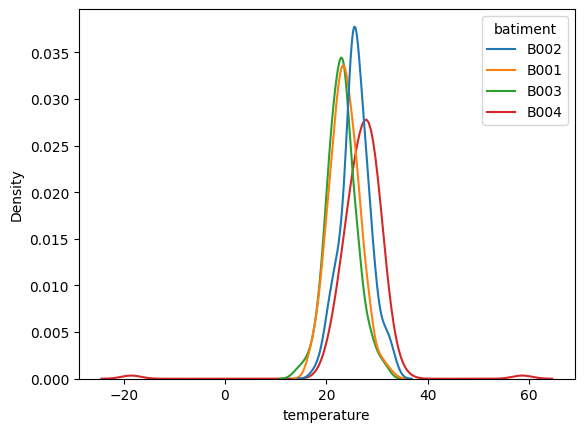

In [51]:
sns.kdeplot(data=df, x="temperature", hue="batiment")

Partie 3 – Distribution d'une variable avec boxplot()
1) Afficher la distribution des températures

Text(0, 0.5, 'temperature')

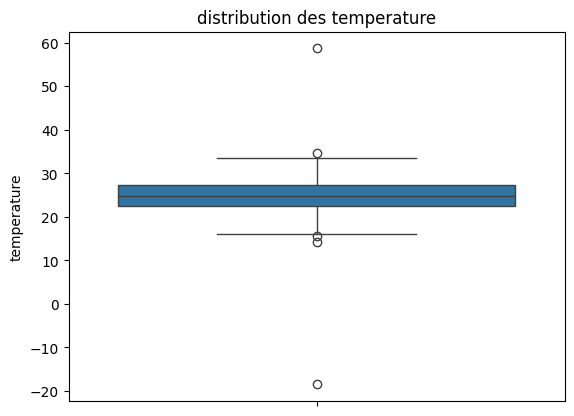

In [52]:
sns.boxplot(y=df["temperature"])
plt.title("distribution des temperature")
plt.ylabel("temperature")


2) Afficher la distribution des températures par bâtiment

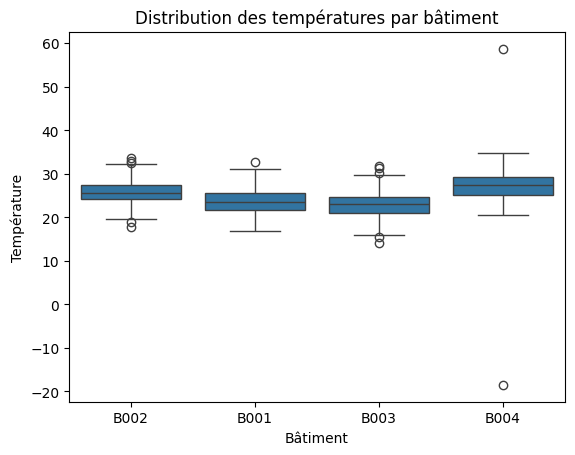

In [53]:
sns.boxplot(x="batiment", y="temperature", data=df)

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température")
plt.show()

3) Pour chaque bâtiment,
a) quelle est la médiane ?

pour le batiment 1 la mediane est : 25
pour le batiment 2 la mediane est : 23
pour le batiment 3 la mediane est : 22
pour le batiment 4 la mediane est : 28


b) quelle est la dispersion ?

In [54]:
df.groupby("batiment")["temperature"].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)

batiment
B001    4.0600
B002    3.2625
B003    3.5125
B004    4.1075
Name: temperature, dtype: float64

c) les valeurs extrêmes

les valeurs extremes pour chaque batiment:
pour le batiment 1 : environ 18 °C, 19 °C, 32 °C, 33 °C
pour le batiment 2 : environ 33 °C  
pour le batiment 3 : environ 14 °C, 15 °C, 30 °C, 31 °C
pour le batiment 4 : environ -19 °C et 58 °C   



Partie 4 – Distribution d'une variable avec violinplot()
1) Afficher la distribution des températures

<Axes: xlabel='temperature'>

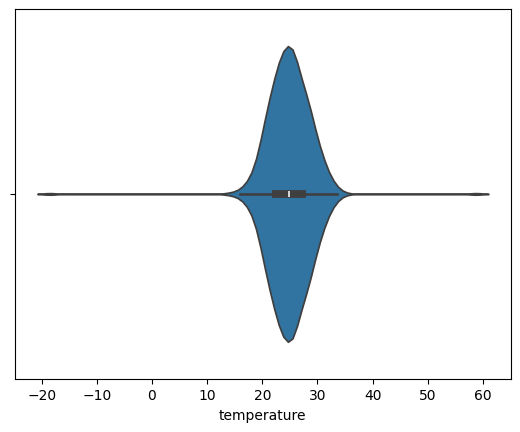

In [55]:
sns.violinplot(data=df, x="temperature")

2) Afficher la distribution des températures par bâtiment

<Axes: xlabel='temperature', ylabel='batiment'>

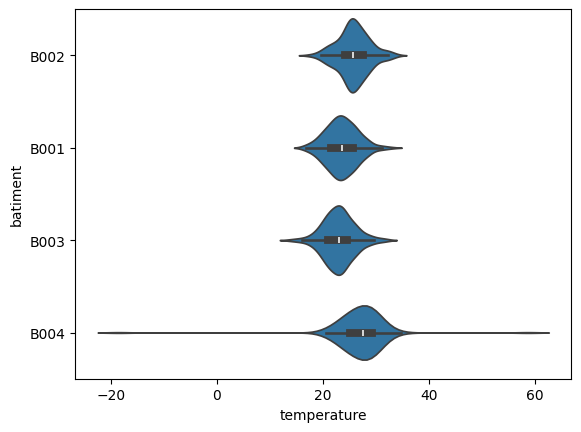

In [56]:
sns.violinplot(data=df, x="temperature", y="batiment")


3) Quelles informations supplémentaires le violin plot permet-il de visualiser par rapport au box
plot ?

Le boxplot permet surtout de voir :

la médiane les quartiles, la dispersion,
les valeurs extrêmes et les éventuels outliers.

Le violin plot contient ces informations mais montre en plus la forme de la distribution, grâce à la largeur du "violon".

Partie 5 – Comptage des catégories avec countplot()
1) Afficher le nombre de mesures par état

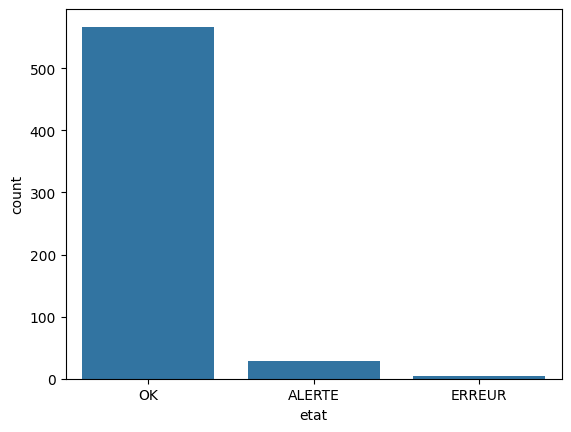

In [57]:
sns.countplot(data=df, x="etat")
plt.show()

In [58]:
2) Afficher le nombre de mesures par bâtiment

SyntaxError: unmatched ')' (1440231734.py, line 1)

<Axes: xlabel='batiment', ylabel='count'>

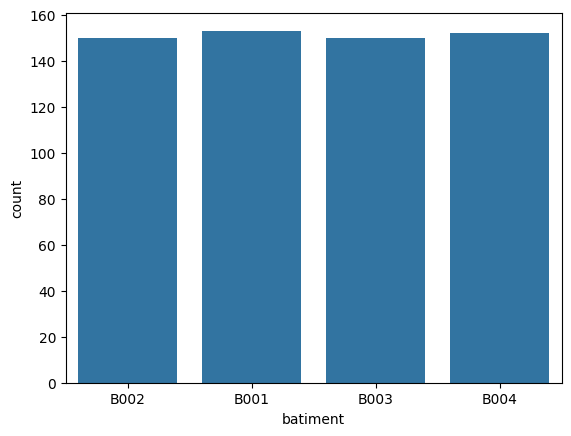

In [ ]:
sns.countplot(data=df, x="batiment")

3) Afficher les états des capteurs par bâtiment pour identifier
a) le bâtiment ayant le plus de mesures en état OK ;
b) celui ayant le plus de mesures en ALERTE ;
c) celui ayant le plus de mesures en ERREUR.

<Axes: xlabel='etat', ylabel='count'>

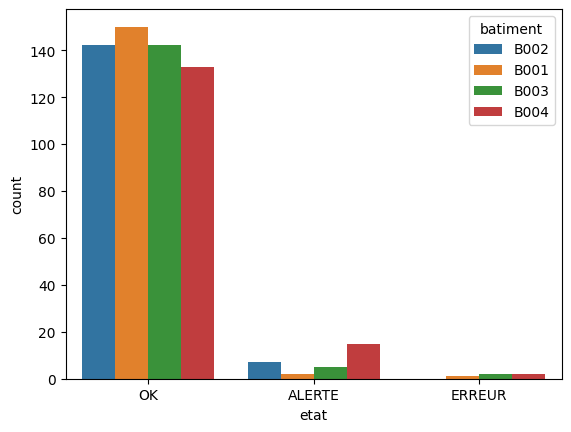

In [59]:
sns.countplot(data=df, x="etat", hue="batiment")

a) le bâtiment ayant le plus de mesures en état OK ;
c'est le batiment B001 : le batiment 1
b) celui ayant le plus de mesures en ALERTE ;
c'est le batiment B004 : batiment 4
c) celui ayant le plus de mesures en ERREUR.
C'est le batiment B003 et B004 batiments 3 et 4

Partie 6 – Relation entre deux variables avec scatterplot()
1) Etudier graphiquement la relation entre température et consommation

<Axes: xlabel='temperature', ylabel='consommation'>

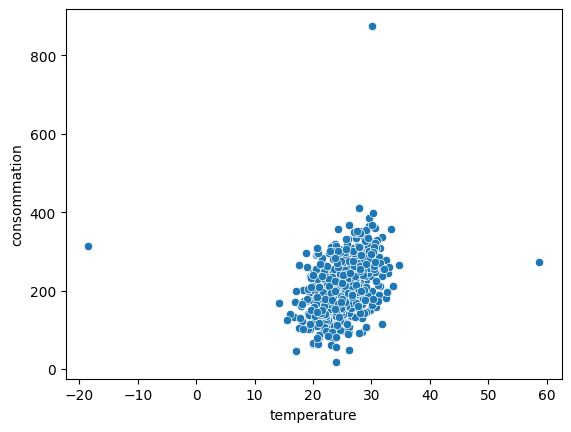

In [65]:
sns.scatterplot(data=df, x="temperature", y="consommation")


2) Etudier graphiquement la relation entre température et consommation par bâtiment

<Axes: xlabel='temperature', ylabel='consommation'>

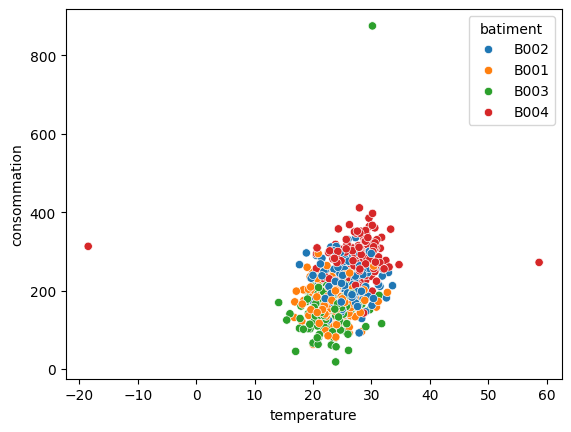

In [66]:
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment")

3) Modifier la taille des points

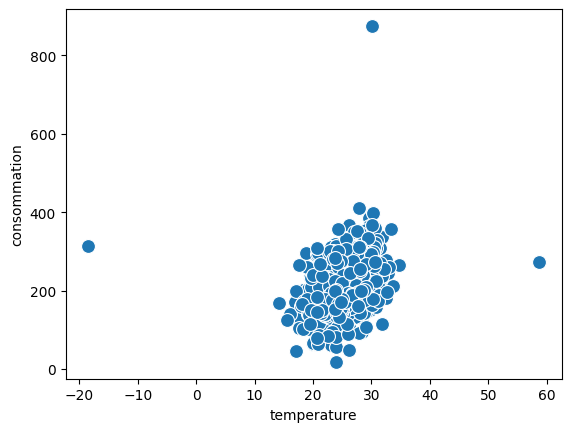

In [67]:
sns.scatterplot(
    data=df,
    x="temperature",
    y="consommation",
    s=100
)
plt.show()

Partie 7 – Régression avec regplot()
Etudier graphiquement une tendance entre température et consommation

<Axes: xlabel='temperature', ylabel='consommation'>

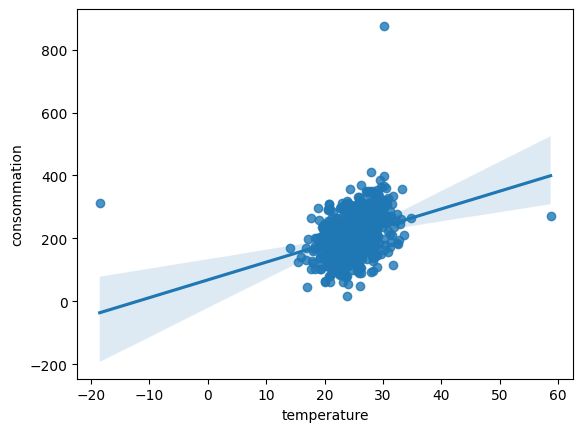

In [68]:
sns.regplot(data=df, x="temperature", y="consommation")

Partie 8 – Régression avec lmplot()
Etudier graphiquement une tendance entre température et consommation par bâtiment

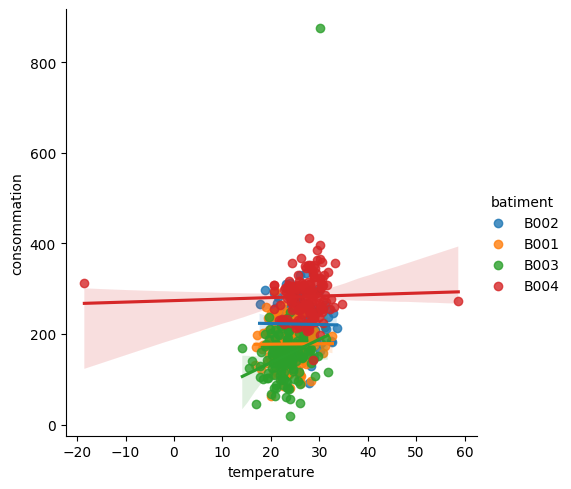

In [75]:
sns.lmplot(
    data=df,
    x="temperature",
    y="consommation",
    hue="batiment"
)
plt.show()

Partie 9 – Corrélations
1) Utiliser Pandas pour calculer les corrélations entre température, humidité, pression et consommation.

In [79]:
colonnes = ["temperature", "humidite", "pression", "consommation"]

correlation = df[colonnes].corr()

print(correlation)

              temperature  humidite  pression  consommation
temperature      1.000000 -0.006126  0.061283      0.317048
humidite        -0.006126  1.000000  0.045242     -0.046061
pression         0.061283  0.045242  1.000000      0.056051
consommation     0.317048 -0.046061  0.056051      1.000000


2) Afficher la matrice de corrélation obtenue avec Pandas

In [80]:
df[colonnes].corr()

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


3) Afficher le heatmap de la corrélation pour identifier :


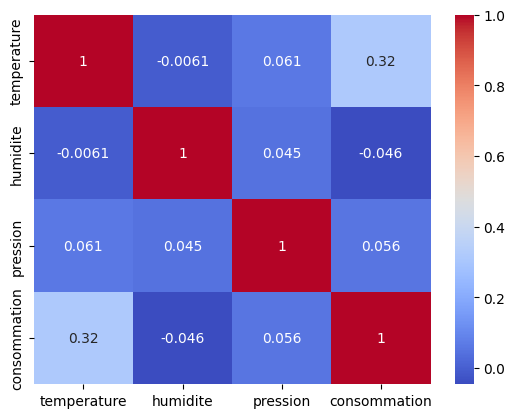

In [81]:
sns.heatmap(
    correlation,
    annot=True,   #permet d'afficher les valeurs numériques directement dans les cases.
    cmap="coolwarm"
)

plt.show()

a) les corrélations positives ;
je ne constate pas de correlation positive
b) les corrélations négatives ;
la pression et la consommatio sont correler negativement de meme que l'humidite et la pression  
c) les corrélations proches de zéro ;
humidite et consommation, humidite et temperature
d) les variables qui semblent fortement liées.

Partie 10 – Analyse multivariée avec pairplot()
En considérant la température, l’humidité, la pression et la consommation, réaliser un graphique qui affiche simultanément les distributions individuelles et les scatter plots entre variables.

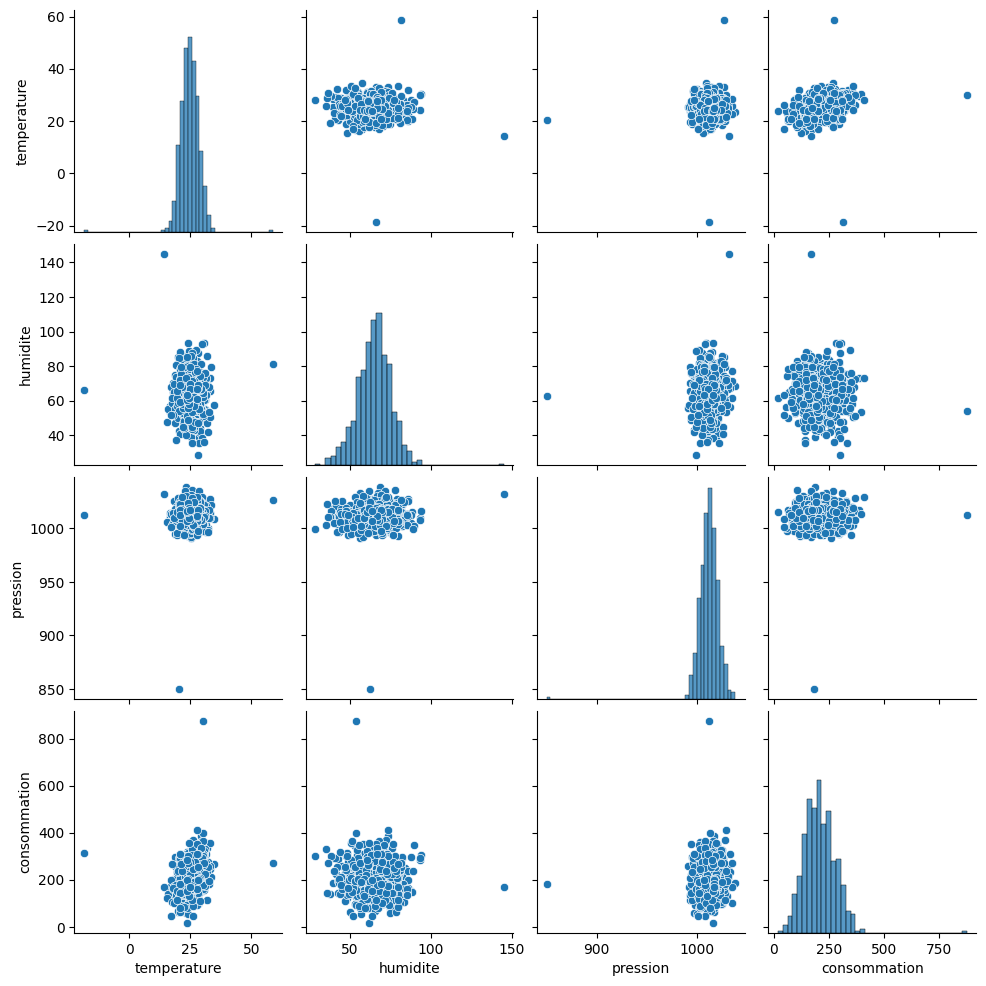

In [83]:
colonnes = ["temperature", "humidite", "pression", "consommation"]
sns.pairplot(df[colonnes])

Partie 11 : Sauvegarde des graphiques
Sauvegarder les graphiques dans le sous-dossier exports

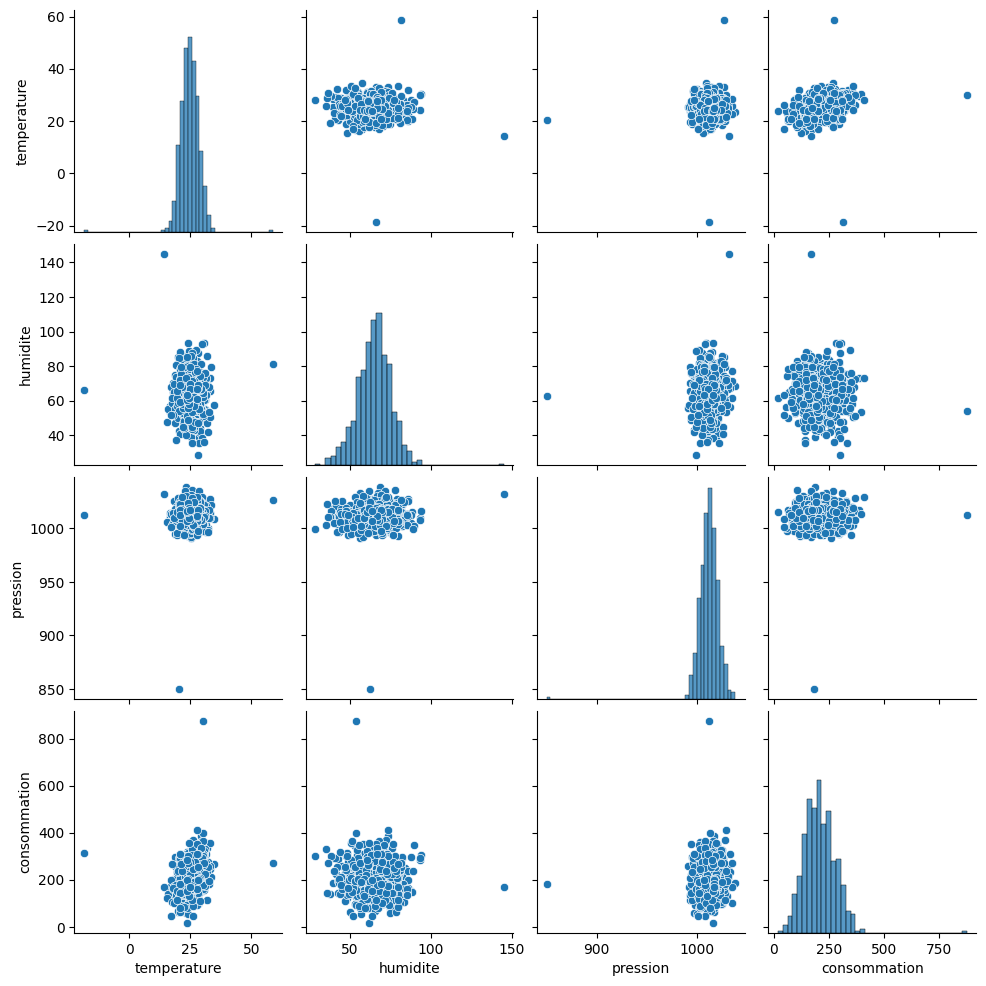

In [86]:
sns.pairplot(df[colonnes])
plt.savefig("../exports/graphiques.png")

BONUS

creation d'un tableau de bord synthétique qui rassemble plusieurs informations :

In [87]:
print("=== ANALYSE DES BÂTIMENTS ===")

print("\nNombre de mesures :")
print(df["batiment"].value_counts())

print("\nTempérature moyenne :")
print(df.groupby("batiment")["temperature"].mean())

print("\nConsommation moyenne :")
print(df.groupby("batiment")["consommation"].mean())

print("\nÉtat des capteurs :")
print(pd.crosstab(df["batiment"], df["etat"]))

=== ANALYSE DES BÂTIMENTS ===

Nombre de mesures :
batiment
B001    153
B004    152
B002    150
B003    150
Name: count, dtype: int64

Température moyenne :
batiment
B001    23.578824
B002    25.778000
B003    23.013699
B004    27.119000
Name: temperature, dtype: float64

Consommation moyenne :
batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64

État des capteurs :
etat      ALERTE  ERREUR   OK
batiment                     
B001           2       1  150
B002           7       0  142
B003           5       2  142
B004          15       2  133
